In [1]:
import sys
import os
sys.path += [ f'{os.environ["HOME"]}/.local/lib/python{sys.version_info.major}.{sys.version_info.minor}/site-packages' ]

# Now we can safely import atlasopenmagic
import atlasopenmagic as atom

In [47]:
import uproot # for reading .root files
import time # to measure time to analyse
import math # for mathematical functions such as square root
import awkward as ak # for handling complex and nested data structures efficiently
import numpy as np # # for numerical calculations such as histogramming
import matplotlib.pyplot as plt # for plotting
from matplotlib.ticker import MaxNLocator,AutoMinorLocator # for minor ticks
from lmfit.models import PolynomialModel, GaussianModel # for the signal and background fits
import vector #to use vectors
import requests # for HTTP access
import aiohttp # HTTP client support
import pandas as pd
import json

import torch
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

from sklearn.neural_network import MLPClassifier

from sklearn import datasets
from sklearn.datasets import fetch_openml
import tensorflow  as tf
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
CONFIG_FILE = "ml_config.json"

with open(CONFIG_FILE, "r") as f:
    config = json.load(f)

In [4]:
checkpoint_dir = config["options"]["checkpoint_dir"]

In [5]:
def load_blackbox(checkpoint_dir="blackbox_checkpoint"):

    # create checkpoint directories
    events_dir = os.path.join(checkpoint_dir, "events")

    print("\nLoading all checkpoint files...")
    
    parquet_files = [os.path.join(events_dir, f) for f in os.listdir(events_dir) if f.endswith(".parquet")]
    
    parquet_files.sort()
    
    if len(parquet_files) == 0:
        raise RuntimeError("No events found in checkpoint.")
    
    for parquet_file in parquet_files:
        ds = ak.from_parquet(parquet_file)
    
    # load and concatenate
    data = ak.from_parquet(parquet_files)
    
    print(f"Loaded {len(data)} events " f"from {len(parquet_files)} parquet files.")
    
    
    # shuffle
    rng = np.random.default_rng(25)
    indices = rng.permutation(len(data))
    data = data[indices]
    
        # labels
    labels = data["label"]
    
    return data, labels

In [6]:
data, labels = load_blackbox(checkpoint_dir)


Loading all checkpoint files...
Loaded 19995 events from 10 parquet files.


In [7]:
data.lep

<Array [{pt: [26.7, ...], eta: ..., ...}, ...] type='19995 * {pt: var * flo...'>

In [8]:
# event selection criteria
mask_exactly2leptons = data.lep.n == 2

In [9]:
for i in range(150, 180):
    print(mask_exactly2leptons[i])
    print(data.lep.n[i])

True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
True
2
False
3
True
2
True
2
True
2
True
2
True
2
True
2


In [10]:
# define mask with filter criterium
data_2lep = data[mask_exactly2leptons]

In [11]:
print("Number of events in the original signal dataset:", len(data))
print("Number of events with at least 2 leptons:", len(data_2lep))

Number of events in the original signal dataset: 19995
Number of events with at least 2 leptons: 19518


In [12]:
# Convert the lepton kinematic variables of the zeroth lepton in each event to PyTorch tensors.
# The [:,0] indexing selects the zeroth lepton from each event.
# We also define the datatype for each array - this makes things faster

lepton0_pt_tensor  = torch.tensor(data_2lep.lep.pt[:,0] , dtype=torch.float32)
lepton0_eta_tensor = torch.tensor(data_2lep.lep.eta[:,0], dtype=torch.float32)
lepton0_phi_tensor = torch.tensor(data_2lep.lep.phi[:,0], dtype=torch.float32)
lepton0_e_tensor   = torch.tensor(data_2lep.lep.e[:,0]  , dtype=torch.float32)

lepton1_pt_tensor  = torch.tensor(data_2lep.lep.pt[:,1] , dtype=torch.float32)
lepton1_eta_tensor = torch.tensor(data_2lep.lep.eta[:,1], dtype=torch.float32)
lepton1_phi_tensor = torch.tensor(data_2lep.lep.phi[:,1], dtype=torch.float32)
lepton1_e_tensor   = torch.tensor(data_2lep.lep.e[:,1]  , dtype=torch.float32)

In [13]:
# stack the tensors into a single tensor
input_tensor = torch.stack([lepton0_pt_tensor,
             lepton0_eta_tensor,
             lepton0_phi_tensor,
             lepton0_e_tensor,
             lepton1_pt_tensor,
             lepton1_eta_tensor,
             lepton1_phi_tensor,
             lepton1_e_tensor,
             ], dim=1)

In [14]:
# define the target
labels_2lep = labels[mask_exactly2leptons]

target_tensor = torch.tensor(labels_2lep, dtype=torch.float32)

In [15]:
target_tensor

tensor([0., 0., 1.,  ..., 0., 0., 1.])

In [16]:
# train test split
X_train, X_test = train_test_split(input_tensor, test_size=0.2, random_state=4)
Y_train, Y_test = train_test_split(target_tensor, test_size=0.2, random_state=4)

In [17]:
# Compute the mean and standard deviation
mean = X_train.mean(dim=0, keepdim=True)
std = X_train.std(dim=0, keepdim=True)

# Transform step: Apply the standardization formula
X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

In [18]:
device = "cpu"
X_train_scaled = X_train_scaled.to(device)
X_test_scaled = X_test_scaled.to(device)

Y_train = Y_train.to(device)
Y_test = Y_test.to(device)

In [37]:
model = nn.Sequential(
    nn.Linear(8, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid(),
)

# Our model should live on the same device as our tensors
model = model.to(device)

In [38]:
# Define the loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [39]:
train_losses = []
test_losses = []

N_epochs = 100

for epoch in range(N_epochs):

    model.train()
    # tell the optimizer to begin an optimization step
    optimizer.zero_grad()

    # forward pass
    # use the model as a prediction function: features → predictions
    predictions = model(X_train_scaled)

    # compute the loss between these predictions and the intended targets
    loss = criterion(predictions.squeeze(), Y_train)

    # Compute the gradients of the loss wrt the trainable parameters
    loss.backward()

    # Update the model parameters based on the gradients
    optimizer.step()

    # Purely for monitoring and visualisation: keeping track of the losses
    train_losses.append(loss.item())


    # validation
    model.eval()

    with torch.no_grad():
        test_predictions = model(X_test_scaled)
        test_loss = criterion(test_predictions.squeeze(), Y_test)

    test_losses.append(test_loss.item())

    print(
        f'Epoch [{epoch + 1}/{N_epochs}], '
        f'Train Loss: {loss.item():.4f}, '
        f'Test Loss: {test_loss.item():.4f}')

Epoch [1/100], Train Loss: 0.7209, Test Loss: 0.6942
Epoch [2/100], Train Loss: 0.6934, Test Loss: 0.6687
Epoch [3/100], Train Loss: 0.6681, Test Loss: 0.6446
Epoch [4/100], Train Loss: 0.6442, Test Loss: 0.6211
Epoch [5/100], Train Loss: 0.6209, Test Loss: 0.5978
Epoch [6/100], Train Loss: 0.5978, Test Loss: 0.5745
Epoch [7/100], Train Loss: 0.5747, Test Loss: 0.5508
Epoch [8/100], Train Loss: 0.5514, Test Loss: 0.5267
Epoch [9/100], Train Loss: 0.5275, Test Loss: 0.5019
Epoch [10/100], Train Loss: 0.5032, Test Loss: 0.4766
Epoch [11/100], Train Loss: 0.4783, Test Loss: 0.4509
Epoch [12/100], Train Loss: 0.4531, Test Loss: 0.4250
Epoch [13/100], Train Loss: 0.4277, Test Loss: 0.3990
Epoch [14/100], Train Loss: 0.4022, Test Loss: 0.3733
Epoch [15/100], Train Loss: 0.3770, Test Loss: 0.3481
Epoch [16/100], Train Loss: 0.3522, Test Loss: 0.3237
Epoch [17/100], Train Loss: 0.3282, Test Loss: 0.3003
Epoch [18/100], Train Loss: 0.3052, Test Loss: 0.2782
Epoch [19/100], Train Loss: 0.2833, T

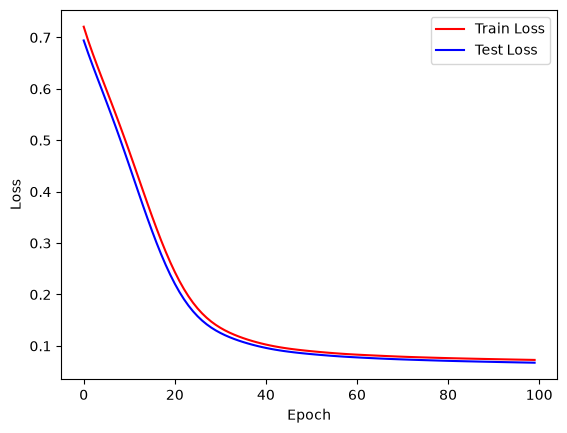

In [ ]:
# plot loss function for training and validation sets
plt.plot(train_losses, label='Train Loss', color='red')
plt.plot(test_losses, label='Test Loss', color='blue')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

tensor([[0.0062],
        [1.0000],
        [0.0084],
        ...,
        [1.0000],
        [1.0000],
        [1.0000]])
0.9777151639344263


Text(0, 0.5, 'Events')

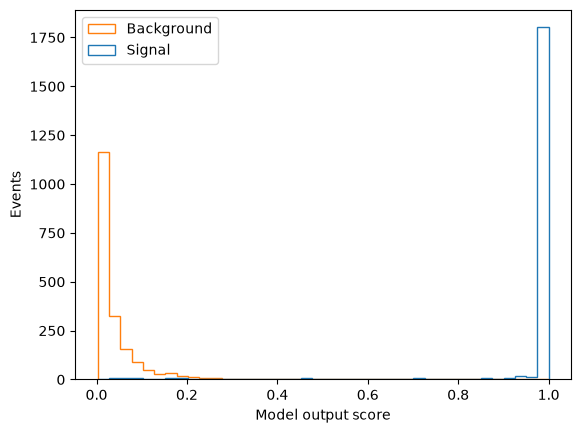

In [41]:
# Model evaluation is simple: call the model
# We detach the array
y_pred = model(X_test_scaled).detach()
print(y_pred)

# Plot the scores
#plt.hist(y_pred,bins=40)
#plt.xlabel('Model output score')
#plt.ylabel('Events')

threshold = 0.5
y_pred_labels = (y_pred >= threshold).float()

accuracy = accuracy_score(Y_test, y_pred_labels)
print(accuracy)

# Plotting the model outputs for signal and background separately
signal_scores = y_pred[Y_test == 1].flatten()
background_scores = y_pred[Y_test == 0].flatten()
plt.hist([signal_scores,background_scores], bins=40, histtype='step', label=['Signal','Background'])
plt.legend()
plt.xlabel('Model output score')
plt.ylabel('Events')

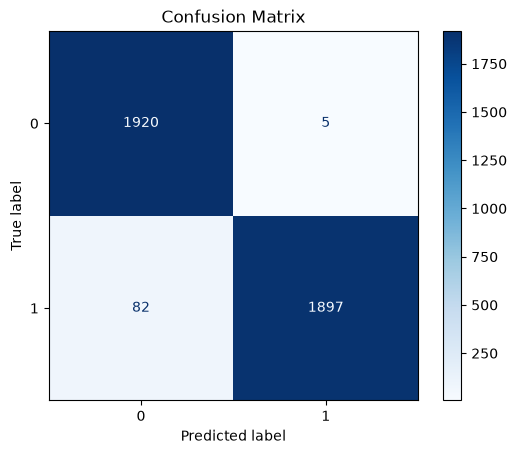

In [42]:
# modell in evaluation mode
model.eval()

with torch.no_grad():
    test_predictions = model(X_test_scaled).squeeze()

    # probabilities
    test_predicted_classes = (test_predictions >= 0.5).int()

# confusion matrix
cm = confusion_matrix(
    Y_test.cpu().numpy(),
    test_predicted_classes.cpu().numpy()
)

# plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [45]:
# =========== Scikit Approach ============ #
nn_deep = MLPClassifier(
    hidden_layer_sizes=(64, 64, 64, 64),   # FOUR hidden layers -- a "deep" network
    activation='relu',
    max_iter=2000,
    random_state=4,
)
nn_deep.fit(X_train_scaled, Y_train)

score_nn_deep_test = nn_deep.predict_proba(X_test_scaled)[:, 1]
score_nn_deep_test

array([4.13061481e-04, 1.00000000e+00, 2.31307256e-05, ...,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00], shape=(3904,))

In [63]:
# =========== TensorFlow Keras Approach ============ #
tf_model = tf.keras.Sequential([
    tf.keras.layers.Dense(512, input_shape=(8,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dropout(0.1),

    tf.keras.layers.Dense(256),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dropout(0.1),

    tf.keras.layers.Dense(64),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dropout(0.1),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

tf_model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, input_shape=(8,)),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

tf_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [64]:
earlystop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0005,
    patience=10,
    restore_best_weights=True
)

low_history = tf_model.fit(input_tensor, target_tensor, epochs=100, batch_size=2048, validation_split=0.2, callbacks=[earlystop])

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5557 - loss: 20.1933 - val_accuracy: 0.5320 - val_loss: 15.7917
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5341 - loss: 14.0835 - val_accuracy: 0.5169 - val_loss: 12.7430
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5294 - loss: 11.5962 - val_accuracy: 0.5172 - val_loss: 9.8796
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5328 - loss: 8.4750 - val_accuracy: 0.5248 - val_loss: 6.6594
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5462 - loss: 5.6096 - val_accuracy: 0.5574 - val_loss: 3.9828
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5888 - loss: 3.2961 - val_accuracy: 0.5935 - val_loss: 3.7381
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6074 - loss: 3.2328 - val_accuracy: 0.6009 - val_loss: 3.4844
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5821 - loss: 2.6588 - val_accuracy: 0.6002 - val_loss: 2

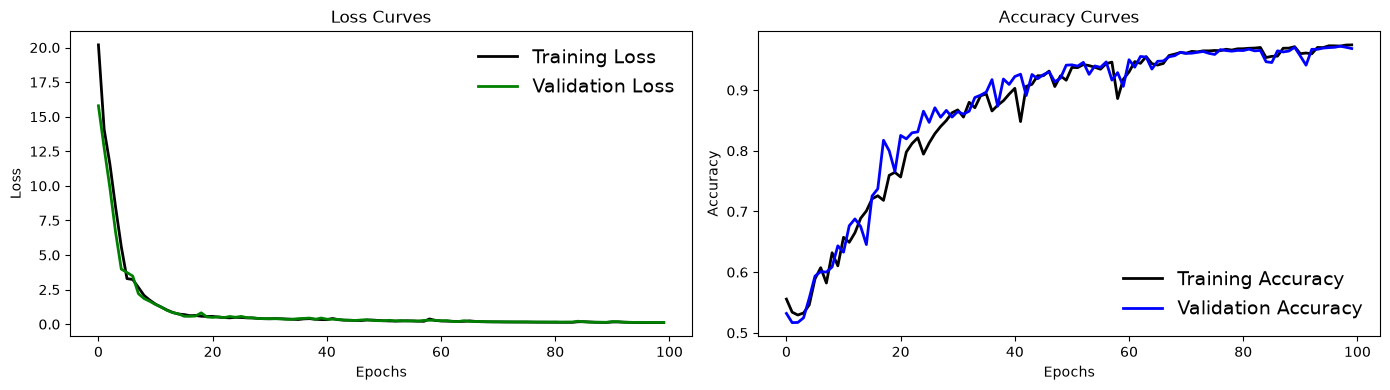

In [65]:
# Loss & Accuracycurve
plt.figure(figsize=[14,4])

plt.subplot(1,2,1)
plt.plot(low_history.history['loss'], 'black', linewidth=2.0)
plt.plot(low_history.history['val_loss'], 'green', linewidth=2.0)
plt.legend(['Training Loss', 'Validation Loss'], frameon=False, fontsize=14)
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.title('Loss Curves', fontsize=12)

plt.subplot(1,2,2)
plt.plot(low_history.history['accuracy'], 'black', linewidth=2.0)
plt.plot(low_history.history['val_accuracy'], 'blue', linewidth=2.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'], frameon=False, fontsize=14)
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)
plt.title('Accuracy Curves', fontsize=12)

plt.tight_layout()
plt.savefig("tf_ml.png")
plt.show()